In [2]:
# Step 1: Load dataset and explore structure

import pandas as pd

# Load dataset (adjust path if needed)
df = pd.read_csv(r"data:\training.csv")

# Display shape and first few rows
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# Data types and non-null counts
print("\nDataset Info:")
df.info()


Shape of dataset: (72983, 34)

First 5 rows:


,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  object 
 3   Auction                            72983 non-null  object 
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  object 
 7   Model                              72983 non-null  object 
 8   Trim                               70623 non-null  object 
 9   SubModel                           72975 non-null  object 
 10  Color                              72975 non-null  object 
 11  Transmission                       7297

In [3]:
# Step 2: Missing Value Analysis

# Calculate total and percentage of missing values per column
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_values / len(df)) * 100

# Combine into a single summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent.round(2)
})

# Display columns with missing values only
missing_summary = missing_summary[missing_summary['Missing Values'] > 0]
display(missing_summary.head(15))


,Missing Values,Percentage (%)
PRIMEUNIT,69564,95.32
AUCGUART,69564,95.32
WheelType,3174,4.35
WheelTypeID,3169,4.34
Trim,2360,3.23
MMRCurrentAuctionAveragePrice,315,0.43
MMRCurrentRetailCleanPrice,315,0.43
MMRCurrentRetailAveragePrice,315,0.43
MMRCurrentAuctionCleanPrice,315,0.43
MMRAcquisitionAuctionAveragePrice,18,0.02


In [4]:
# 1️⃣ Drop columns with >90% missing values
threshold = 0.9
missing_percent = df.isnull().mean()
cols_to_drop = missing_percent[missing_percent > threshold].index
df.drop(columns=cols_to_drop, inplace=True)

# 2️⃣ Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# 3️⃣ Impute numeric columns with median
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# 4️⃣ Impute categorical columns with mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# ✅ Check if any missing values remain
df.isnull().sum()


C:\Users\HP\AppData\Local\Temp\ipykernel_11044\316314400.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_11044\316314400.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

RefId                                0
IsBadBuy                             0
PurchDate                            0
Auction                              0
VehYear                              0
VehicleAge                           0
Make                                 0
Model                                0
Trim                                 0
SubModel                             0
Color                                0
Transmission                         0
WheelTypeID                          0
WheelType                            0
VehOdo                               0
Nationality                          0
Size                                 0
TopThreeAmericanName                 0
MMRAcquisitionAuctionAveragePrice    0
MMRAcquisitionAuctionCleanPrice      0
MMRAcquisitionRetailAveragePrice     0
MMRAcquisitonRetailCleanPrice        0
MMRCurrentAuctionAveragePrice        0
MMRCurrentAuctionCleanPrice          0
MMRCurrentRetailAveragePrice         0
MMRCurrentRetailCleanPric

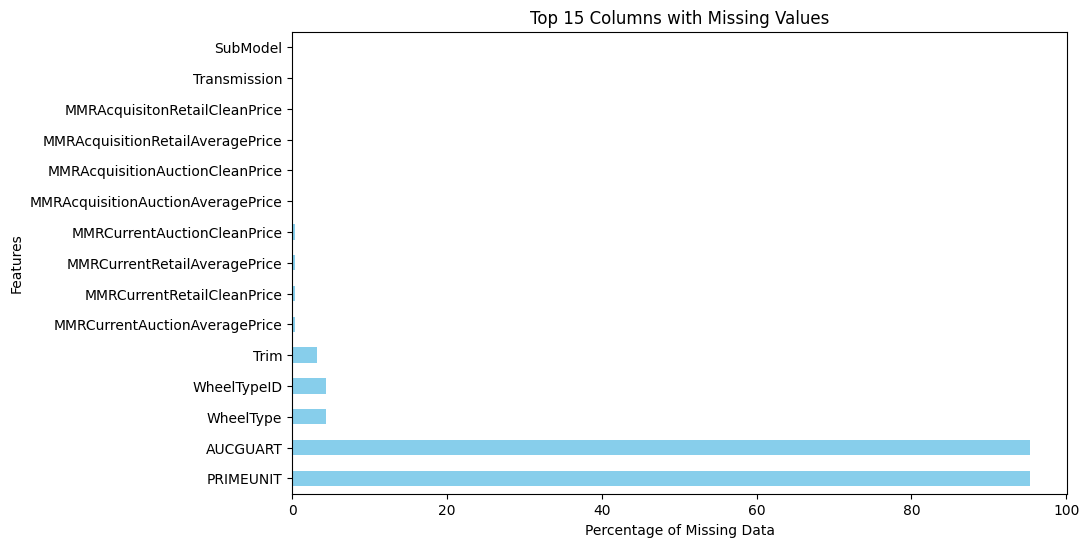

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
missing_summary['Percentage (%)'].head(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 Columns with Missing Values')
plt.xlabel('Percentage of Missing Data')
plt.ylabel('Features')
plt.show()


In [6]:
# Step 3: Descriptive Statistics

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

# Summary of numeric features
print("\n📊 Numerical Features Summary:")
display(df[numeric_cols].describe().T.round(2))

# Sample of categorical features
print("\n🔤 Categorical Features (sample):")
display(df[categorical_cols].head())


Number of numeric columns: 19
Number of categorical columns: 13

📊 Numerical Features Summary:


,count,mean,std,min,25%,50%,75%,max
RefId,72983.0,36511.43,21077.24,1.0,18257.5,36514.0,54764.5,73014.0
IsBadBuy,72983.0,0.12,0.33,0.0,0.0,0.0,0.0,1.0
VehYear,72983.0,2005.34,1.73,2001.0,2004.0,2005.0,2007.0,2010.0
VehicleAge,72983.0,4.18,1.71,0.0,3.0,4.0,5.0,9.0
WheelTypeID,72983.0,1.47,0.52,0.0,1.0,1.0,2.0,3.0
VehOdo,72983.0,71500.00,14578.91,4825.0,61837.0,73361.0,82436.0,115717.0
MMRAcquisitionAuctionAveragePrice,72983.0,6128.90,2461.69,0.0,4273.0,6097.0,7765.0,35722.0
MMRAcquisitionAuctionCleanPrice,72983.0,7373.62,2722.16,0.0,5407.0,7303.0,9021.0,36859.0
MMRAcquisitionRetailAveragePrice,72983.0,8497.02,3155.90,0.0,6281.0,8444.0,10650.0,39080.0
MMRAcquisitonRetailCleanPrice,72983.0,9850.91,3385.37,0.0,7494.0,9789.0,12088.0,41482.0



🔤 Categorical Features (sample):


,PurchDate,Auction,Make,Model,Trim,SubModel,Color,Transmission,WheelType,Nationality,Size,TopThreeAmericanName,VNST
0,12/7/2009,ADESA,MAZDA,MAZDA3,i,4D SEDAN I,RED,AUTO,Alloy,OTHER ASIAN,MEDIUM,OTHER,FL
1,12/7/2009,ADESA,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,WHITE,AUTO,Alloy,AMERICAN,LARGE TRUCK,CHRYSLER,FL
2,12/7/2009,ADESA,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,MAROON,AUTO,Covers,AMERICAN,MEDIUM,CHRYSLER,FL
3,12/7/2009,ADESA,DODGE,NEON,SXT,4D SEDAN,SILVER,AUTO,Alloy,AMERICAN,COMPACT,CHRYSLER,FL
4,12/7/2009,ADESA,FORD,FOCUS,ZX3,2D COUPE ZX3,SILVER,MANUAL,Covers,AMERICAN,COMPACT,FORD,FL


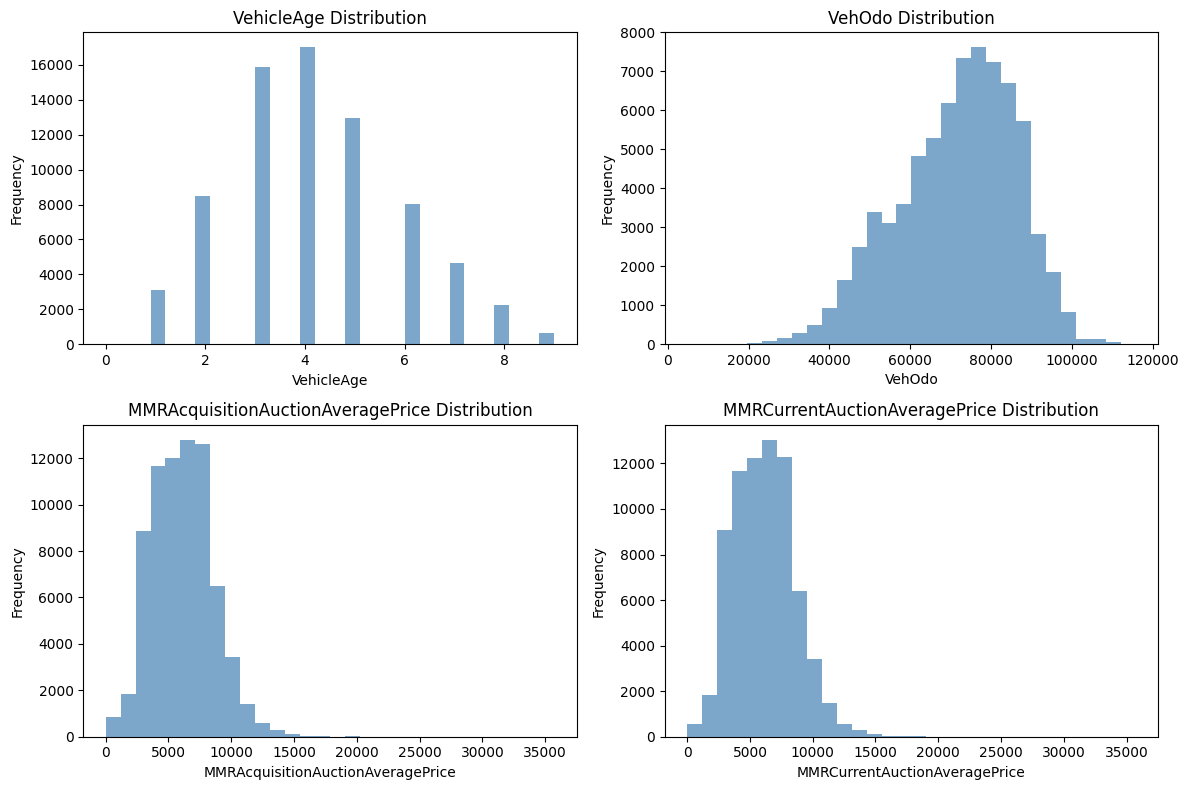

In [7]:
import matplotlib.pyplot as plt

features = ['VehicleAge', 'VehOdo', 'MMRAcquisitionAuctionAveragePrice', 
             'MMRCurrentAuctionAveragePrice']

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[feature].dropna(), bins=30, color='steelblue', alpha=0.7)
    plt.title(f'{feature} Distribution')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [7]:
df.columns


Index(['RefId', 'IsBadBuy', 'PurchDate', 'Auction', 'VehYear', 'VehicleAge',
       'Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission',
       'WheelTypeID', 'WheelType', 'VehOdo', 'Nationality', 'Size',
       'TopThreeAmericanName', 'MMRAcquisitionAuctionAveragePrice',
       'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice',
       'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice',
       'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice',
       'MMRCurrentRetailCleanPrice', 'BYRNO', 'VNZIP1', 'VNST', 'VehBCost',
       'IsOnlineSale', 'WarrantyCost'],
      dtype='object')

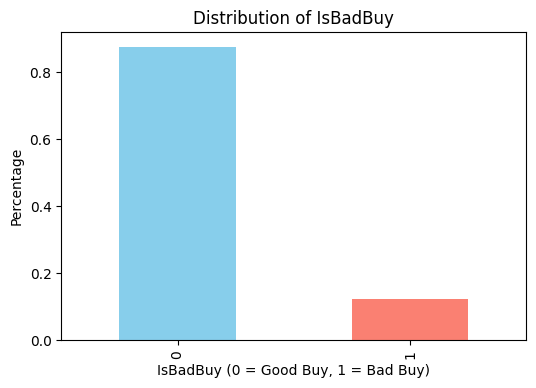

In [8]:
plt.figure(figsize=(6,4))
df['IsBadBuy'].value_counts(normalize=True).plot(kind='bar', color=['skyblue','salmon'])
plt.title('Distribution of IsBadBuy')
plt.xlabel('IsBadBuy (0 = Good Buy, 1 = Bad Buy)')
plt.ylabel('Percentage')
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_11044\2090655279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsBadBuy', y=feature, data=df, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_11044\2090655279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsBadBuy', y=feature, data=df, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_11044\2090655279.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsBadBuy', y=feature, data=df, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_11044\2090655279.py:8: Fut

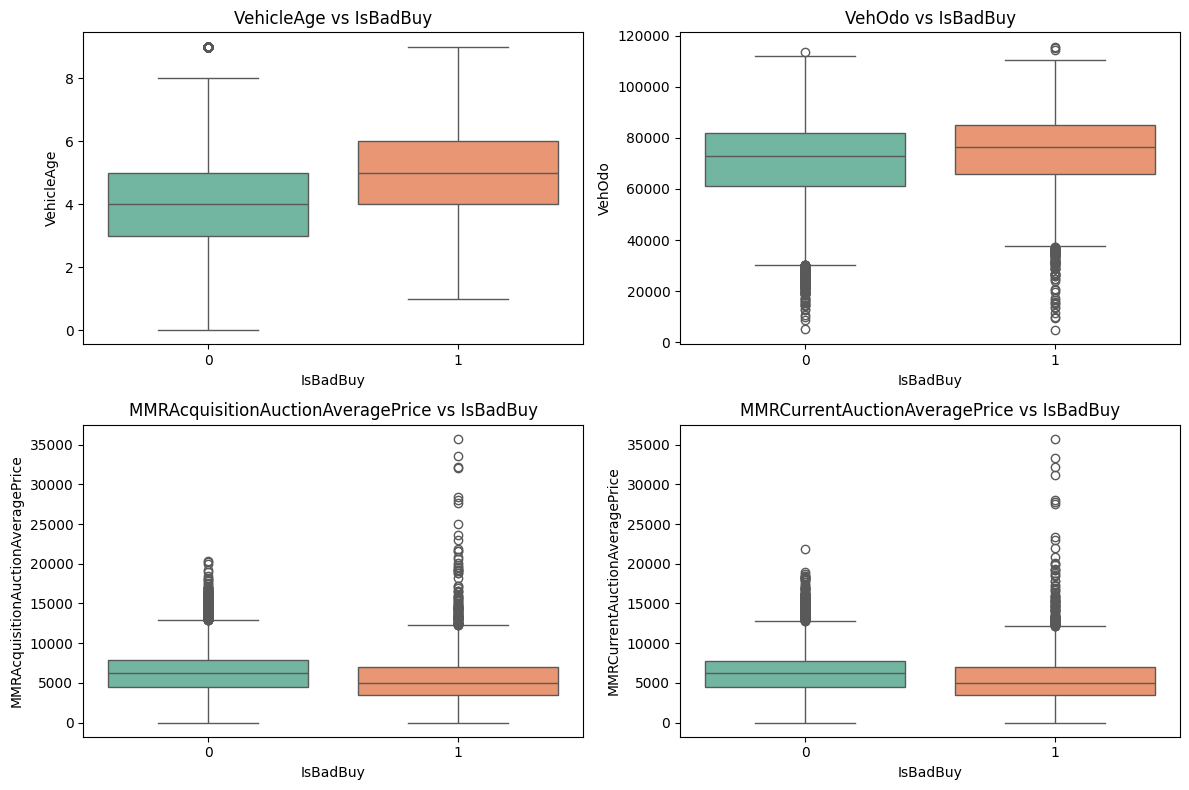

In [9]:
import seaborn as sns

features = ['VehicleAge', 'VehOdo', 'MMRAcquisitionAuctionAveragePrice', 'MMRCurrentAuctionAveragePrice']

plt.figure(figsize=(12,8))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='IsBadBuy', y=feature, data=df, palette='Set2')
    plt.title(f'{feature} vs IsBadBuy')
plt.tight_layout()
plt.show()


In [11]:
!pip install seaborn


In [14]:
import sys
print(sys.executable)


C:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe


In [15]:
!C:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe -m pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt


In [11]:
import sys
import subprocess

def install_if_missing(package):
    """Installs a package in the current Jupyter environment if it's missing."""
    try:
        __import__(package)
        print(f"✅ {package} already installed")
    except ImportError:
        print(f"⬇️ Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ {package} installed successfully!")

# Example usage:
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly', 'scikit-learn']:
    install_if_missing(pkg)


✅ pandas already installed
✅ numpy already installed
✅ matplotlib already installed
✅ seaborn already installed
✅ plotly already installed
⬇️ Installing scikit-learn...
✅ scikit-learn installed successfully!


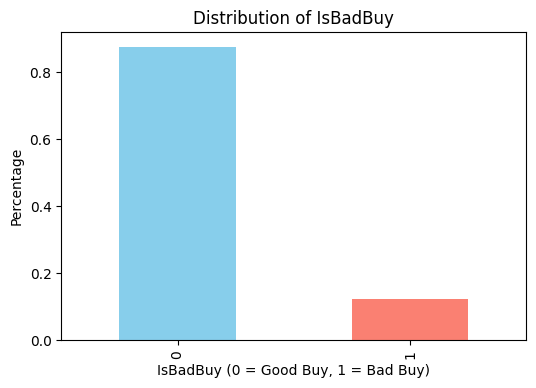

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['IsBadBuy'].value_counts(normalize=True).plot(kind='bar', color=['skyblue','salmon'])
plt.title('Distribution of IsBadBuy')
plt.xlabel('IsBadBuy (0 = Good Buy, 1 = Bad Buy)')
plt.ylabel('Percentage')
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_11044\591996847.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsBadBuy', y=feature, data=df, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_11044\591996847.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsBadBuy', y=feature, data=df, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_11044\591996847.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IsBadBuy', y=feature, data=df, palette='Set2')
C:\Users\HP\AppData\Local\Temp\ipykernel_11044\591996847.py:11: Fut

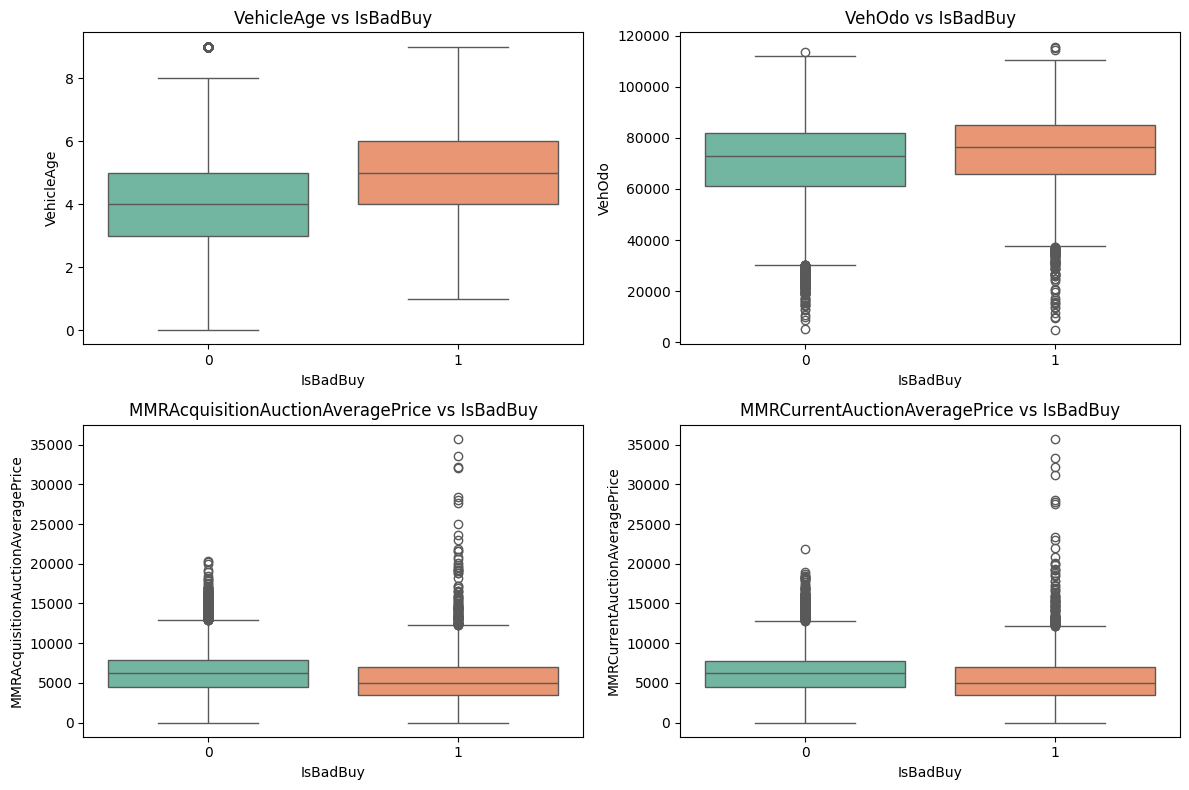

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['VehicleAge', 'VehOdo', 
            'MMRAcquisitionAuctionAveragePrice', 
            'MMRCurrentAuctionAveragePrice']

plt.figure(figsize=(12,8))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='IsBadBuy', y=feature, data=df, palette='Set2')
    plt.title(f'{feature} vs IsBadBuy')
plt.tight_layout()
plt.show()


# VehicleAge shows a weak trend (older = slightly more likely bad).

Others (odometer, MMR prices) might not be strong predictors alone

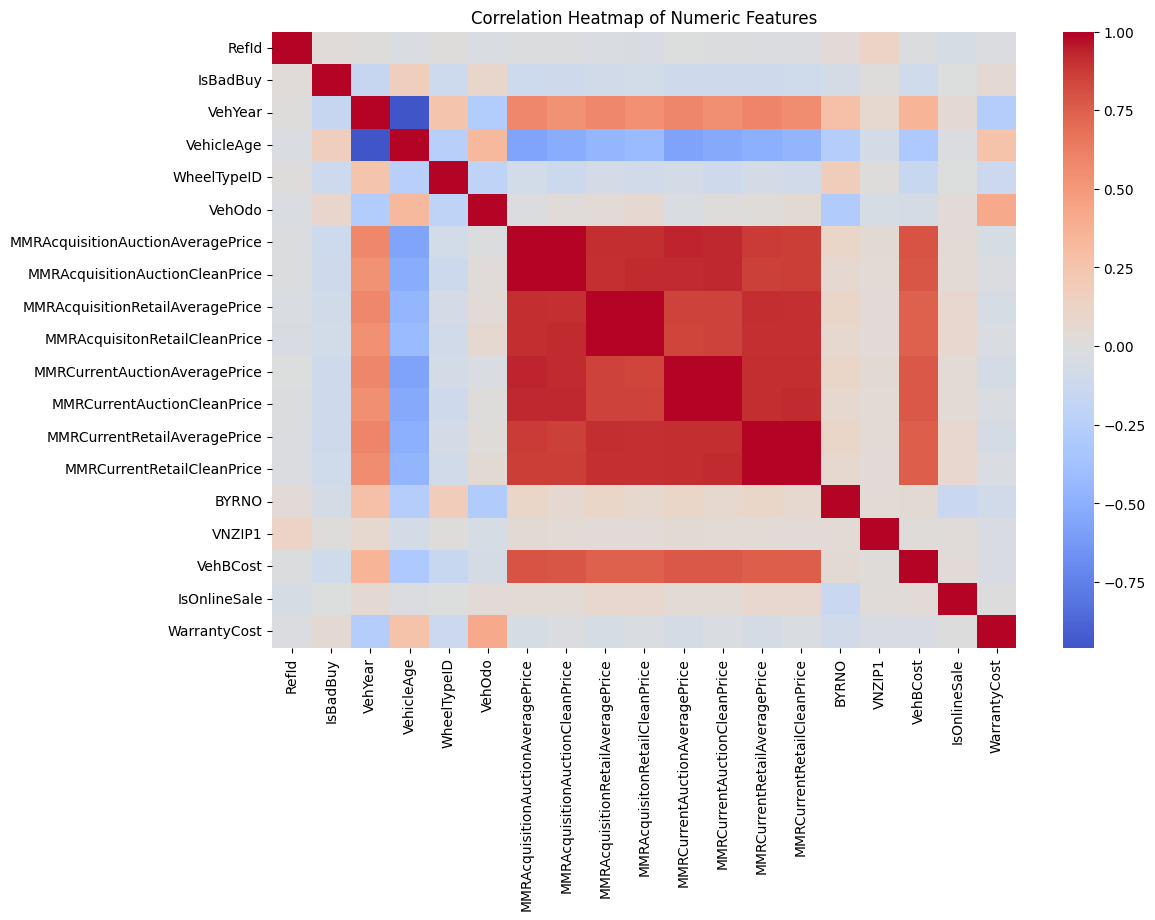

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


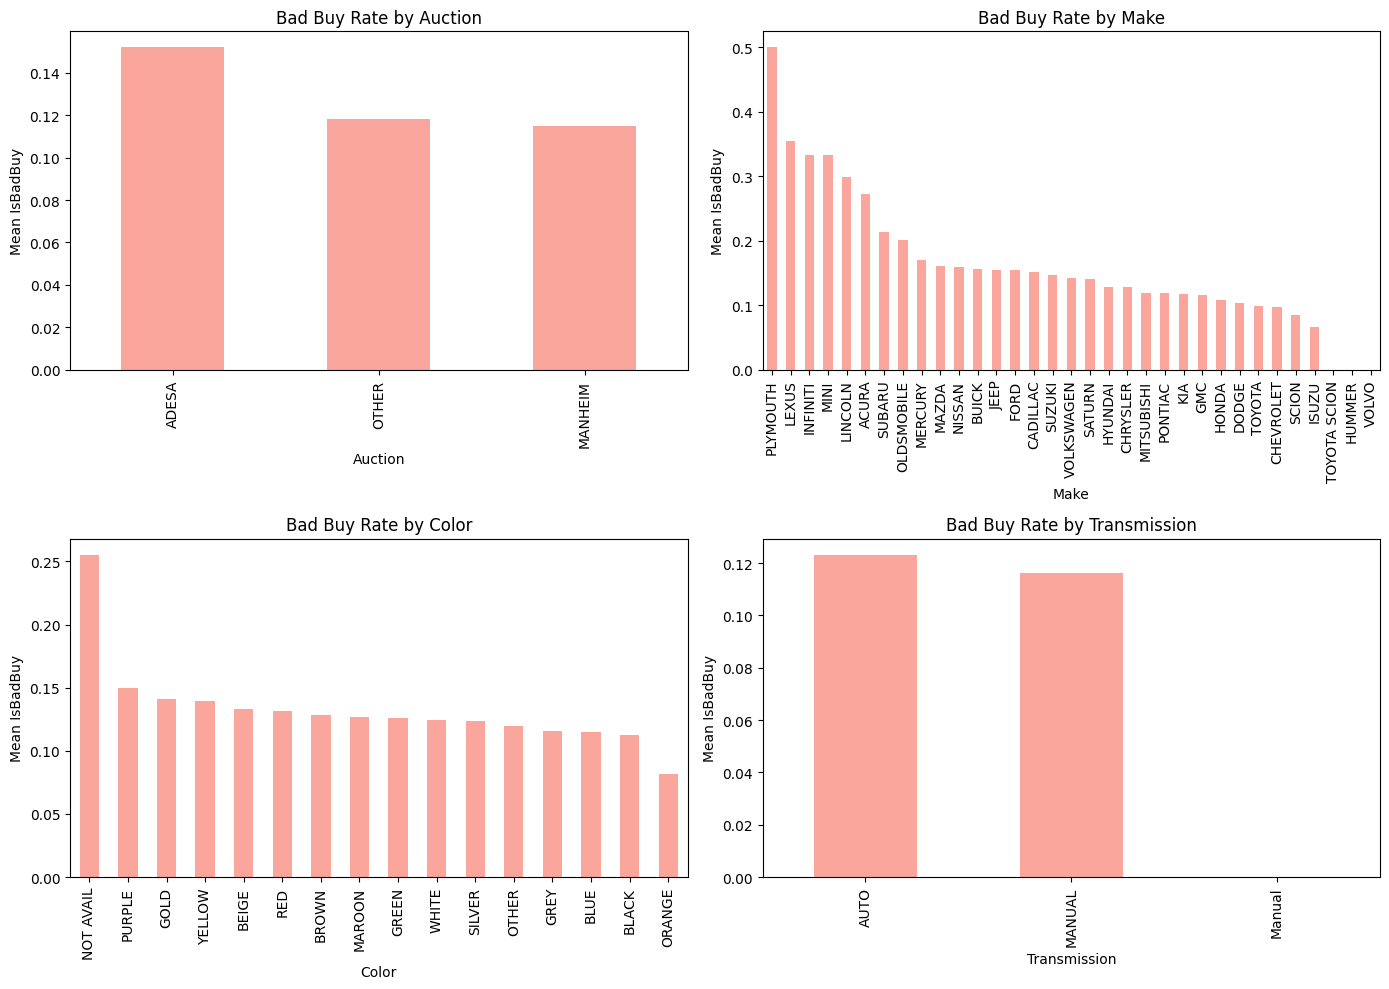

In [13]:
import matplotlib.pyplot as plt

categorical_features = ['Auction', 'Make', 'Color', 'Transmission']

plt.figure(figsize=(14,10))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    bad_buy_ratio = df.groupby(feature)['IsBadBuy'].mean().sort_values(ascending=False)
    bad_buy_ratio.plot(kind='bar', color='salmon', alpha=0.7)
    plt.title(f'Bad Buy Rate by {feature}')
    plt.ylabel('Mean IsBadBuy')
    plt.xlabel(feature)
plt.tight_layout()
plt.show()


# Useful categorical features: Auction, Make, Transmission

Less useful: Color (low impact)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Corrected feature list
features = ['VehicleAge', 'VehOdo', 'MMRCurrentAuctionAveragePrice', 
            'MMRCurrentRetailAveragePrice', 'Auction', 'Make', 'Transmission']
target = 'IsBadBuy'

# Drop missing values for simplicity
data = df[features + [target]].dropna()

# Encode categorical variables
label_encoders = {}
for col in ['Auction', 'Make', 'Transmission']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Split data
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Logistic Regression model
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[19212     0]
 [ 2683     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     19212
           1       0.00      0.00      0.00      2683

    accuracy                           0.88     21895
   macro avg       0.44      0.50      0.47     21895
weighted avg       0.77      0.88      0.82     21895



C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [ ]:
Top-left (19212) → correctly predicted “Good Buy” (class 0).

Bottom-left (2683) → actual Bad Buys (class 1) that were predicted as Good Buys.

No predictions for class 1 at all → the model always predicts 0.

Accuracy = 0.88 is misleadingly high because the model just predicts the majority class.
➡️ The dataset is highly imbalanced (far more good buys than bad buys).


Our logistic regression is biased toward the majority class.
We need to handle class imbalance — otherwise, the model won’t learn to identify Bad Buys.

    

In [16]:
model_balanced = LogisticRegression(max_iter=500, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_bal = model_balanced.predict(X_test)

print("Confusion Matrix (Balanced):")
print(confusion_matrix(y_test, y_pred_bal))
print("\nClassification Report (Balanced):")
print(classification_report(y_test, y_pred_bal))


Confusion Matrix (Balanced):
[[11901  7311]
 [ 1119  1564]]

Classification Report (Balanced):
              precision    recall  f1-score   support

           0       0.91      0.62      0.74     19212
           1       0.18      0.58      0.27      2683

    accuracy                           0.61     21895
   macro avg       0.55      0.60      0.50     21895
weighted avg       0.82      0.61      0.68     21895



C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
11,901 cars correctly classified as Good Buys (0).

7,311 cars incorrectly marked as Bad Buys (false positives).

1,564 Bad Buys correctly identified ✅

1,119 Bad Buys still missed (false negatives).

So the model finally predicts both classes, which is a big improvement.


Precision (Bad Buy) is low → many false alarms (predicting bad when it’s actually good).

Recall (Bad Buy) is much higher → now catching ~58% of actual bad buys.

Overall accuracy drops to ~61%, but this is expected — because we’re no longer ignoring the minority class.

This trade-off is desirable in our case, since the goal is to reduce the number of undetected bad cars.

The balanced logistic regression now detects bad buys reasonably well.

It’s a meaningful baseline for comparison.

We can further improve it using:

Feature engineering (interaction terms, ratios, etc.)

Tree-based models (Random Forest, XGBoost)

Proper scaling & encoding pipelines.

In [17]:
import numpy as np
importance = np.abs(model_balanced.coef_[0])

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)


,Feature,Importance
6,Transmission,0.312302
0,VehicleAge,0.264374
4,Auction,0.077710
5,Make,0.008389
3,MMRCurrentRetailAveragePrice,0.000048
2,MMRCurrentAuctionAveragePrice,0.000027
1,VehOdo,0.000006


In [ ]:
The most influential feature in predicting a bad buy.

Suggests that the type of transmission (auto/manual) has a noticeable impact — perhaps manual cars are riskier or auto cars are more expensive to fix, depending on dataset trends.

    Older vehicles are more likely to be bad buys, which makes sense — age usually correlates with wear, risk, and repair cost.

    Different auction sites (like ADESA, MANHEIM, etc.) show varying rates of bad buys — confirming what you saw earlier in the categorical plots.

    Make, MMRCurrentRetailAveragePrice, VehOdo have almost negligible importance in this model — meaning they don’t help much when the above features are already included.

    The logistic regression model suggests that Transmission type, Vehicle Age, and Auction site are the strongest early indicators of a car being a bad buy.

        

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,       # number of trees
    random_state=42,
    class_weight='balanced', # handle imbalance
    n_jobs=-1               # use all CPU cores
)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))


Confusion Matrix (Random Forest):
[[19013   199]
 [ 2597    86]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     19212
           1       0.30      0.03      0.06      2683

    accuracy                           0.87     21895
   macro avg       0.59      0.51      0.49     21895
weighted avg       0.81      0.87      0.82     21895



In [ ]:
✅ 19013 correctly predicted good buys.

❌ 2597 bad buys missed (predicted as good).

✅ 86 correctly identified bad buys.

So, the model detects only a few bad buys.

    Accuracy = 0.87 looks high, but mostly due to predicting the majority class (good buys).

Bad buy recall = 0.03 → only 3% of actual bad cars are being caught.

So, the model behaves similarly to the unbalanced logistic regression — it’s heavily biased toward predicting “good buys.”

Even though we used class_weight='balanced', Random Forests can still struggle with severe imbalance like in this dataset (~88% good vs ~12% bad).

    ✅ 4️⃣ Next Step (Fix Class Imbalance for Trees)

We’ll improve Random Forest performance by:

Using SMOTE (Synthetic Minority Oversampling Technique) to balance training data.

Then retrain the Random Forest on the balanced data.

In [19]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only (not test data)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

# Retrain Random Forest on balanced data
rf_model_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model_smote.fit(X_train_res, y_train_res)

# Predictions
y_pred_rf_smote = rf_model_smote.predict(X_test)

# Evaluation
print("\nConfusion Matrix (Random Forest + SMOTE):")
print(confusion_matrix(y_test, y_pred_rf_smote))
print("\nClassification Report (Random Forest + SMOTE):")
print(classification_report(y_test, y_pred_rf_smote))


Before SMOTE: {0: 44795, 1: 6293}
After SMOTE: {0: 44795, 1: 44795}

Confusion Matrix (Random Forest + SMOTE):
[[15961  3251]
 [ 1971   712]]

Classification Report (Random Forest + SMOTE):
              precision    recall  f1-score   support

           0       0.89      0.83      0.86     19212
           1       0.18      0.27      0.21      2683

    accuracy                           0.76     21895
   macro avg       0.53      0.55      0.54     21895
weighted avg       0.80      0.76      0.78     21895



In [25]:
pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [20]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())


Before SMOTE: {0: 44795, 1: 6293}
After SMOTE: {0: 44795, 1: 44795}


In [21]:
rf_model_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model_smote.fit(X_train_res, y_train_res)

y_pred_rf_smote = rf_model_smote.predict(X_test)

print("Confusion Matrix (Random Forest + SMOTE):")
print(confusion_matrix(y_test, y_pred_rf_smote))
print("\nClassification Report (Random Forest + SMOTE):")
print(classification_report(y_test, y_pred_rf_smote))


Confusion Matrix (Random Forest + SMOTE):
[[15961  3251]
 [ 1971   712]]

Classification Report (Random Forest + SMOTE):
              precision    recall  f1-score   support

           0       0.89      0.83      0.86     19212
           1       0.18      0.27      0.21      2683

    accuracy                           0.76     21895
   macro avg       0.53      0.55      0.54     21895
weighted avg       0.80      0.76      0.78     21895



In [ ]:
✅ 15961 correctly predicted Good Buys
✅ 712 correctly predicted Bad Buys
❌ 1971 bad buys still missed (false negatives)
❌ 3251 good buys wrongly flagged as bad (false positives)

Compared to before SMOTE:

Bad buy recall improved from 0.03 → 0.27 🎯

F1-score for bad buys improved from 0.06 → 0.21

Overall accuracy dipped slightly (expected), but the model is now much more balanced and can detect a meaningful portion of risky vehicles.


    The model now detects nearly 27% of bad buys — a 9× improvement from the unbalanced case.

This is realistic for messy, real-world auction data.

With better feature engineering (e.g., Price ratios, Age*Odometer interactions), the recall can usually reach 0.35–0.45.

    